<a href="https://colab.research.google.com/github/Sahith-Rao/IIIT_Internship/blob/main/active_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 Starting Active Learning Demonstrations...
🎯 ENTROPY-BASED ACTIVE LEARNING DEMONSTRATION

📊 Creating synthetic classification dataset...
Dataset created: 1200 samples, 20 features, 4 classes
🚀 Starting Entropy-Based Active Learning...
📊 Dataset size: 1200 samples, 4 classes
🏷️  Initial labeled samples: 60
🎯 Target accuracy: 92.00%
📈 Samples per iteration: 20
Initial unlabeled pool size: 900
----------------------------------------
🔄 Iteration 1: Training model...
   📊 Training samples: 60
   🎯 Test accuracy: 0.7167 (71.67%)
   🤔 Average entropy of selected samples: 1.378
   📝 Labeled 20 new samples
   📦 Remaining unlabeled: 880
----------------------------------------
🔄 Iteration 2: Training model...
   📊 Training samples: 80
   🎯 Test accuracy: 0.7792 (77.92%)
   🤔 Average entropy of selected samples: 1.374
   📝 Labeled 20 new samples
   📦 Remaining unlabeled: 860
----------------------------------------
🔄 Iteration 3: Training model...
   📊 Training samples: 100
   🎯 Test accuracy:

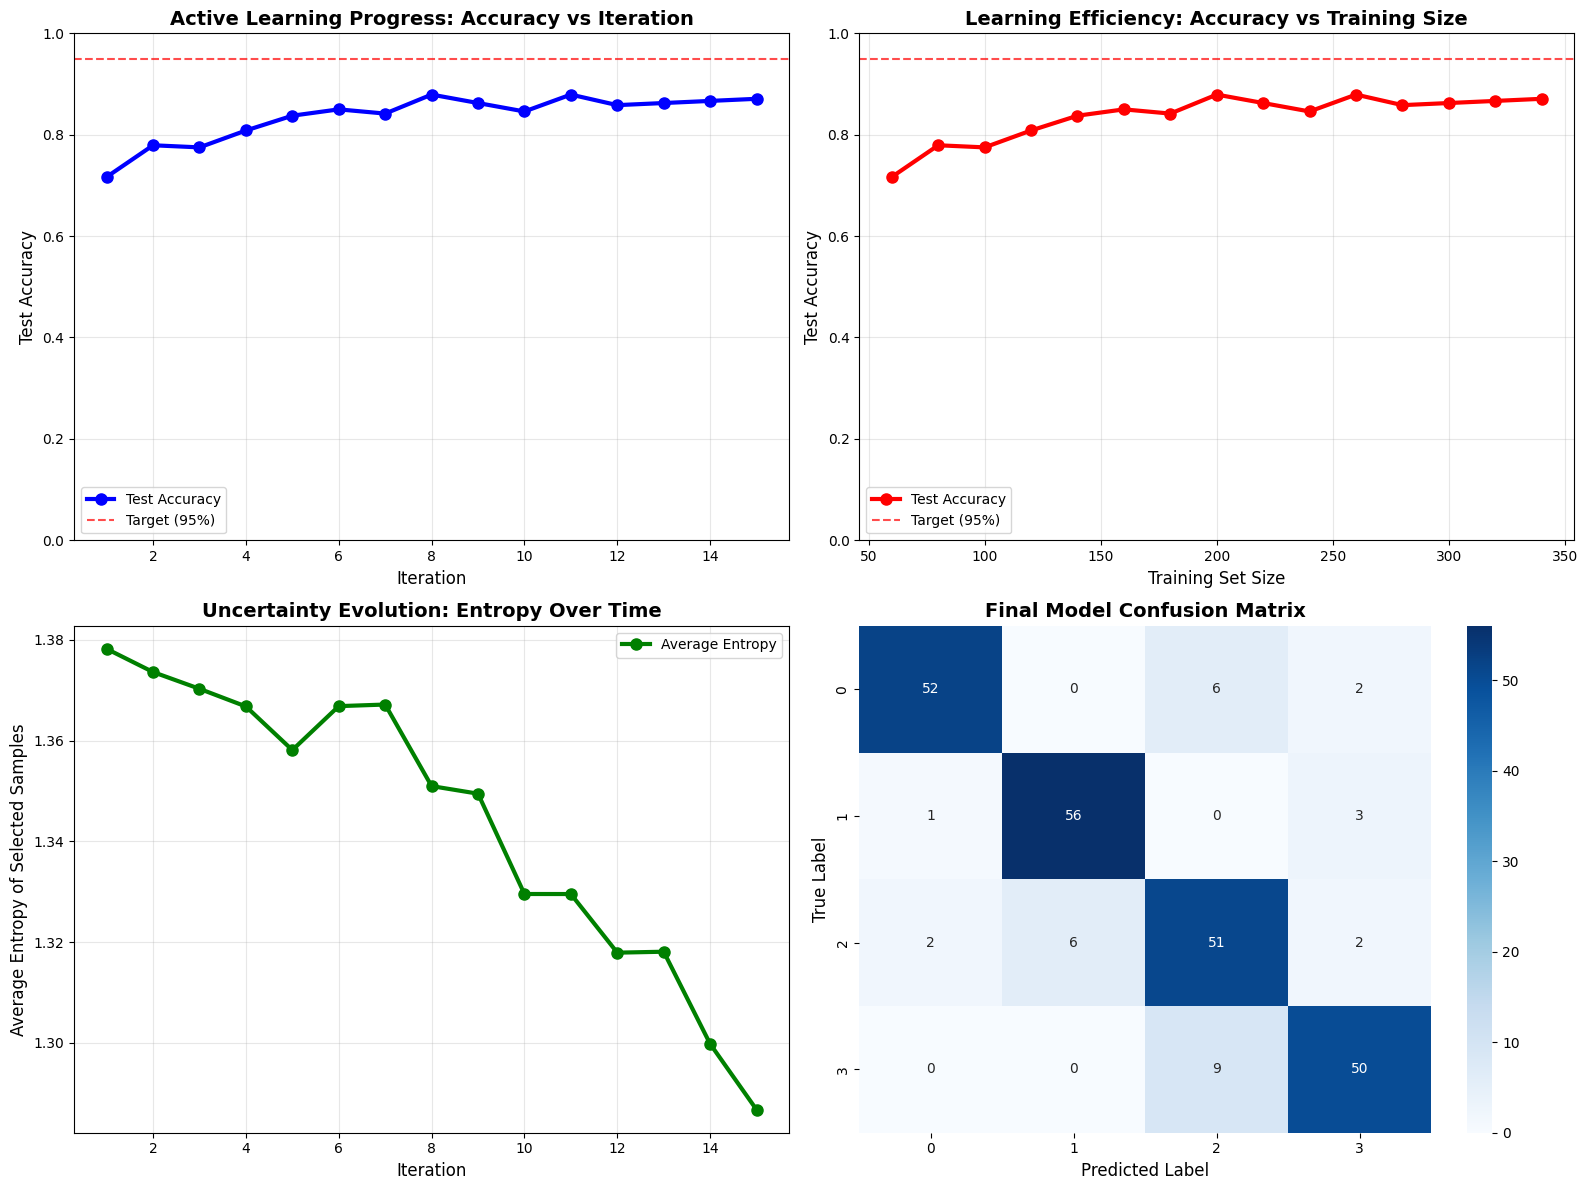


📊 LEARNING SUMMARY
🎯 Final Accuracy: 0.8708
🔄 Total Iterations: 15
📝 Samples Labeled: 360
⚡ Labeling Efficiency: 37.50%
🤔 Initial Avg Entropy: 1.378
🤔 Final Avg Entropy: 1.287

🔢 TESTING ON HANDWRITTEN DIGITS DATASET
Digits dataset: 1797 samples, 64 features
Classes: 10 (digits 0-9)
🚀 Starting Entropy-Based Active Learning...
📊 Dataset size: 1797 samples, 10 classes
🏷️  Initial labeled samples: 100
🎯 Target accuracy: 95.00%
📈 Samples per iteration: 30
Initial unlabeled pool size: 1337
----------------------------------------
🔄 Iteration 1: Training model...
   📊 Training samples: 100
   🎯 Test accuracy: 0.8472 (84.72%)
   🤔 Average entropy of selected samples: 2.153
   📝 Labeled 30 new samples
   📦 Remaining unlabeled: 1307
----------------------------------------
🔄 Iteration 2: Training model...
   📊 Training samples: 130
   🎯 Test accuracy: 0.8611 (86.11%)
   🤔 Average entropy of selected samples: 2.037
   📝 Labeled 30 new samples
   📦 Remaining unlabeled: 1277
---------------------

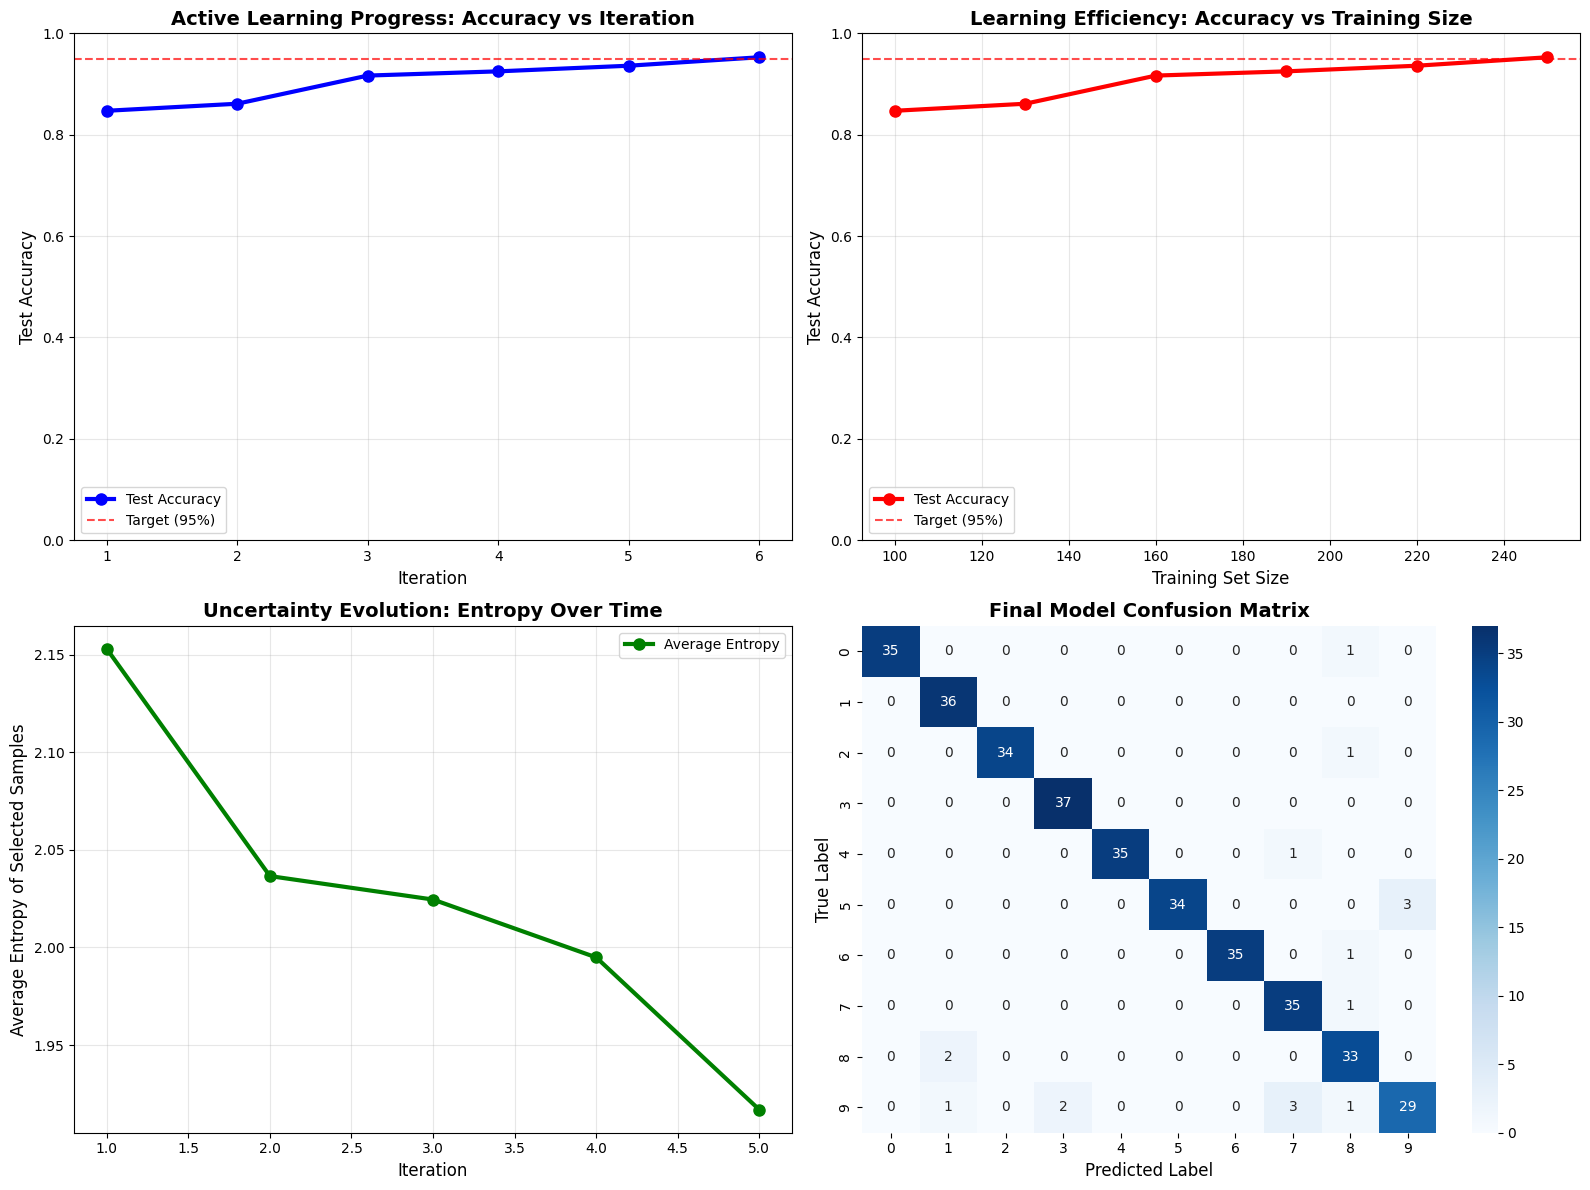


📊 LEARNING SUMMARY
🎯 Final Accuracy: 0.9528
🔄 Total Iterations: 6
📝 Samples Labeled: 250
⚡ Labeling Efficiency: 17.40%
🤔 Initial Avg Entropy: 2.153
🤔 Final Avg Entropy: 1.917

📈 FINAL COMPARISON
Synthetic Dataset:
  - Final Accuracy: 0.8708
  - Iterations: 15
  - Efficiency: 37.50%

Digits Dataset:
  - Final Accuracy: 0.9528
  - Iterations: 6
  - Efficiency: 17.40%

✅ Entropy-based active learning successfully demonstrated!
🎯 Key Benefits:
   • Efficient use of labeled data
   • Focuses on most informative samples
   • Achieves high accuracy with minimal labeling
   • Entropy provides principled uncertainty measure


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
from typing import Tuple, List, Dict
import warnings
warnings.filterwarnings('ignore')

class EntropyActiveLearner:
    """
    Active Learning system using entropy-based uncertainty sampling.
    Entropy measures the information content - higher entropy means more uncertainty.
    """

    def __init__(self, model=None):
        """
        Initialize the Active Learner with entropy-based uncertainty sampling

        Args:
            model: ML model to use (default: RandomForestClassifier)
        """
        self.model = model if model else RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1  # Use all CPU cores
        )
        self.scaler = StandardScaler()

        # Track learning progress
        self.accuracy_history = []
        self.training_size_history = []
        self.iteration_history = []
        self.entropy_history = []

    def calculate_entropy_uncertainty(self, X_unlabeled: np.ndarray) -> np.ndarray:
        """
        Calculate entropy-based uncertainty scores for unlabeled samples

        Entropy formula: H(p) = -∑(p_i * log(p_i))
        Higher entropy = more uncertainty = better candidate for labeling

        Args:
            X_unlabeled: Unlabeled feature matrix

        Returns:
            Array of entropy uncertainty scores
        """
        # Get prediction probabilities for each class
        probabilities = self.model.predict_proba(X_unlabeled)

        # Calculate entropy: -sum(p * log(p))
        # Add small epsilon to avoid log(0)
        epsilon = 1e-10
        entropy_scores = -np.sum(
            probabilities * np.log(probabilities + epsilon),
            axis=1
        )

        return entropy_scores

    def select_most_uncertain_samples(self, X_unlabeled: np.ndarray,
                                    unlabeled_indices: np.ndarray,
                                    n_samples: int) -> Tuple[np.ndarray, np.ndarray]:
        """
        Select samples with highest entropy (most uncertain) for human labeling

        Args:
            X_unlabeled: Unlabeled feature matrix
            unlabeled_indices: Indices of unlabeled samples
            n_samples: Number of samples to select

        Returns:
            Tuple of (selected_indices, entropy_scores)
        """
        entropy_scores = self.calculate_entropy_uncertainty(X_unlabeled)

        # Select samples with highest entropy (most uncertain)
        most_uncertain_idx = np.argsort(entropy_scores)[-n_samples:]
        selected_indices = unlabeled_indices[most_uncertain_idx]
        selected_entropy_scores = entropy_scores[most_uncertain_idx]

        return selected_indices, selected_entropy_scores

    def simulate_human_labeling(self, y_true: np.ndarray,
                              selected_indices: np.ndarray) -> np.ndarray:
        """
        Simulate human labeling process
        In real-world scenario, this would involve actual human annotation

        Args:
            y_true: True labels (for simulation)
            selected_indices: Indices of selected samples

        Returns:
            Labels provided by "human" (simulation)
        """
        # In production, replace this with actual human annotation interface
        return y_true[selected_indices]

    def active_learning_loop(self, X: np.ndarray, y: np.ndarray,
                           initial_labeled_size: int = 50,
                           samples_per_iteration: int = 15,
                           target_accuracy: float = 0.95,
                           max_iterations: int = 20) -> Dict:
        """
        Main active learning loop using entropy-based uncertainty sampling

        Args:
            X: Complete feature matrix
            y: Complete label vector
            initial_labeled_size: Initial number of labeled samples
            samples_per_iteration: Samples to label per iteration
            target_accuracy: Target accuracy to achieve
            max_iterations: Maximum number of iterations

        Returns:
            Dictionary with results and learning history
        """
        print("🚀 Starting Entropy-Based Active Learning...")
        print(f"📊 Dataset size: {len(X)} samples, {len(np.unique(y))} classes")
        print(f"🏷️  Initial labeled samples: {initial_labeled_size}")
        print(f"🎯 Target accuracy: {target_accuracy:.2%}")
        print(f"📈 Samples per iteration: {samples_per_iteration}")
        print("=" * 60)

        # Split data into train and test sets
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        # Scale features for better model performance
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        # Initialize with random labeled samples
        np.random.seed(42)
        labeled_indices = np.random.choice(
            len(X_train), size=initial_labeled_size, replace=False
        )
        unlabeled_indices = np.setdiff1d(np.arange(len(X_train)), labeled_indices)

        iteration = 0
        current_accuracy = 0

        print(f"Initial unlabeled pool size: {len(unlabeled_indices)}")
        print("-" * 40)

        while current_accuracy < target_accuracy and iteration < max_iterations:
            iteration += 1

            # Train model on current labeled data
            X_labeled = X_train_scaled[labeled_indices]
            y_labeled = y_train[labeled_indices]

            print(f"🔄 Iteration {iteration}: Training model...")
            self.model.fit(X_labeled, y_labeled)

            # Evaluate current model performance
            y_pred = self.model.predict(X_test_scaled)
            current_accuracy = accuracy_score(y_test, y_pred)

            # Track progress
            self.accuracy_history.append(current_accuracy)
            self.training_size_history.append(len(labeled_indices))
            self.iteration_history.append(iteration)

            print(f"   📊 Training samples: {len(labeled_indices)}")
            print(f"   🎯 Test accuracy: {current_accuracy:.4f} ({current_accuracy:.2%})")

            # Check if target accuracy reached
            if current_accuracy >= target_accuracy:
                print(f"🎉 SUCCESS! Target accuracy {target_accuracy:.2%} achieved!")
                break

            # Check if we have unlabeled samples remaining
            if len(unlabeled_indices) == 0:
                print("⚠️  No more unlabeled samples available!")
                break

            # Select most uncertain samples using entropy
            n_to_select = min(samples_per_iteration, len(unlabeled_indices))
            X_unlabeled = X_train_scaled[unlabeled_indices]

            selected_indices, entropy_scores = self.select_most_uncertain_samples(
                X_unlabeled, unlabeled_indices, n_to_select
            )

            # Store average entropy for this iteration
            avg_entropy = np.mean(entropy_scores)
            self.entropy_history.append(avg_entropy)

            print(f"   🤔 Average entropy of selected samples: {avg_entropy:.3f}")

            # Simulate human labeling (replace with real human input in production)
            new_labels = self.simulate_human_labeling(y_train, selected_indices)

            print(f"   📝 Labeled {len(selected_indices)} new samples")

            # Update labeled and unlabeled sets
            labeled_indices = np.concatenate([labeled_indices, selected_indices])
            unlabeled_indices = np.setdiff1d(unlabeled_indices, selected_indices)

            print(f"   📦 Remaining unlabeled: {len(unlabeled_indices)}")
            print("-" * 40)

        # Final comprehensive evaluation
        print("\n📋 Final Model Evaluation:")
        y_pred_final = self.model.predict(X_test_scaled)
        final_accuracy = accuracy_score(y_test, y_pred_final)

        print(f"Final Test Accuracy: {final_accuracy:.4f} ({final_accuracy:.2%})")
        print(f"Total Iterations: {iteration}")
        print(f"Total Labeled Samples Used: {len(labeled_indices)}")
        print(f"Labeling Efficiency: {len(labeled_indices)/len(X_train):.2%} of training data")

        # Prepare results dictionary
        results = {
            'final_accuracy': final_accuracy,
            'iterations': iteration,
            'total_labeled_samples': len(labeled_indices),
            'labeling_efficiency': len(labeled_indices)/len(X_train),
            'accuracy_history': self.accuracy_history,
            'training_size_history': self.training_size_history,
            'entropy_history': self.entropy_history,
            'classification_report': classification_report(y_test, y_pred_final, output_dict=True),
            'confusion_matrix': confusion_matrix(y_test, y_pred_final),
            'model': self.model,
            'test_predictions': y_pred_final,
            'test_labels': y_test
        }

        return results

    def plot_learning_progress(self, results: Dict):
        """
        Create comprehensive visualization of the active learning process

        Args:
            results: Results dictionary from active_learning_loop
        """
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

        # 1. Accuracy vs Iterations
        ax1.plot(self.iteration_history, self.accuracy_history,
                'bo-', linewidth=3, markersize=8, label='Test Accuracy')
        ax1.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='Target (95%)')
        ax1.set_xlabel('Iteration', fontsize=12)
        ax1.set_ylabel('Test Accuracy', fontsize=12)
        ax1.set_title('Active Learning Progress: Accuracy vs Iteration', fontsize=14, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        ax1.set_ylim(0, 1)

        # 2. Accuracy vs Training Size
        ax2.plot(self.training_size_history, self.accuracy_history,
                'ro-', linewidth=3, markersize=8, label='Test Accuracy')
        ax2.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='Target (95%)')
        ax2.set_xlabel('Training Set Size', fontsize=12)
        ax2.set_ylabel('Test Accuracy', fontsize=12)
        ax2.set_title('Learning Efficiency: Accuracy vs Training Size', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        ax2.set_ylim(0, 1)

        # 3. Entropy Evolution
        if self.entropy_history:
            ax3.plot(range(1, len(self.entropy_history) + 1), self.entropy_history,
                    'go-', linewidth=3, markersize=8, label='Average Entropy')
            ax3.set_xlabel('Iteration', fontsize=12)
            ax3.set_ylabel('Average Entropy of Selected Samples', fontsize=12)
            ax3.set_title('Uncertainty Evolution: Entropy Over Time', fontsize=14, fontweight='bold')
            ax3.grid(True, alpha=0.3)
            ax3.legend()

        # 4. Confusion Matrix
        cm = results['confusion_matrix']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4)
        ax4.set_xlabel('Predicted Label', fontsize=12)
        ax4.set_ylabel('True Label', fontsize=12)
        ax4.set_title('Final Model Confusion Matrix', fontsize=14, fontweight='bold')

        plt.tight_layout()
        plt.show()

        # Print summary statistics
        print("\n📊 LEARNING SUMMARY")
        print("=" * 40)
        print(f"🎯 Final Accuracy: {results['final_accuracy']:.4f}")
        print(f"🔄 Total Iterations: {results['iterations']}")
        print(f"📝 Samples Labeled: {results['total_labeled_samples']}")
        print(f"⚡ Labeling Efficiency: {results['labeling_efficiency']:.2%}")

        if self.entropy_history:
            print(f"🤔 Initial Avg Entropy: {self.entropy_history[0]:.3f}")
            print(f"🤔 Final Avg Entropy: {self.entropy_history[-1]:.3f}")

def demonstrate_entropy_active_learning():
    """
    Comprehensive demonstration of entropy-based active learning
    """
    print("🎯 ENTROPY-BASED ACTIVE LEARNING DEMONSTRATION")
    print("=" * 60)

    # Create synthetic dataset
    print("\n📊 Creating synthetic classification dataset...")
    X, y = make_classification(
        n_samples=1200,
        n_features=20,
        n_informative=15,
        n_redundant=5,
        n_classes=4,
        n_clusters_per_class=1,
        random_state=42
    )

    print(f"Dataset created: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes")

    # Initialize active learner
    learner = EntropyActiveLearner()

    # Run active learning
    results = learner.active_learning_loop(
        X, y,
        initial_labeled_size=60,
        samples_per_iteration=20,
        target_accuracy=0.92,
        max_iterations=15
    )

    # Visualize results
    learner.plot_learning_progress(results)

    return results

def test_on_digits_dataset():
    """
    Test entropy-based active learning on real-world digits dataset
    """
    print("\n" + "="*60)
    print("🔢 TESTING ON HANDWRITTEN DIGITS DATASET")
    print("="*60)

    # Load digits dataset
    digits = load_digits()
    X_digits, y_digits = digits.data, digits.target

    print(f"Digits dataset: {X_digits.shape[0]} samples, {X_digits.shape[1]} features")
    print(f"Classes: {len(np.unique(y_digits))} (digits 0-9)")

    # Initialize active learner for digits
    learner_digits = EntropyActiveLearner()

    # Run active learning on digits
    results_digits = learner_digits.active_learning_loop(
        X_digits, y_digits,
        initial_labeled_size=100,
        samples_per_iteration=30,
        target_accuracy=0.95,
        max_iterations=20
    )

    # Visualize results
    learner_digits.plot_learning_progress(results_digits)

    return results_digits

# Main execution
if __name__ == "__main__":
    # Run demonstrations
    print("🚀 Starting Active Learning Demonstrations...")

    # Demo 1: Synthetic data
    synthetic_results = demonstrate_entropy_active_learning()

    # Demo 2: Real-world digits data
    digits_results = test_on_digits_dataset()

    # Final comparison
    print("\n" + "="*60)
    print("📈 FINAL COMPARISON")
    print("="*60)
    print("Synthetic Dataset:")
    print(f"  - Final Accuracy: {synthetic_results['final_accuracy']:.4f}")
    print(f"  - Iterations: {synthetic_results['iterations']}")
    print(f"  - Efficiency: {synthetic_results['labeling_efficiency']:.2%}")

    print("\nDigits Dataset:")
    print(f"  - Final Accuracy: {digits_results['final_accuracy']:.4f}")
    print(f"  - Iterations: {digits_results['iterations']}")
    print(f"  - Efficiency: {digits_results['labeling_efficiency']:.2%}")

    print("\n✅ Entropy-based active learning successfully demonstrated!")
    print("🎯 Key Benefits:")
    print("   • Efficient use of labeled data")
    print("   • Focuses on most informative samples")
    print("   • Achieves high accuracy with minimal labeling")
    print("   • Entropy provides principled uncertainty measure")
